In [ ]:
from pyspark.sql import SparkSession

# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("MAST30034 Tutorial 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/02 15:05:36 WARN Utils: Your hostname, Dinadis-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.143 instead (on interface en0)
26/10/02 15:05:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/02 15:05:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# Reading in the SA2 spatial boundary data
from urllib.request import urlretrieve
import os
import zipfile
import geopandas as gpd
from glob import glob

# ABS SA2 boundary file (2021, GDA2020)
ABS_SPATIAL_FILES = {
    "SA2_2021_AUST_SHP_GDA2020.zip":
    "https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs/edition-3-july-2021-june-2026/access-and-downloads/digital-boundary-files/SA2_2021_AUST_SHP_GDA2020.zip"
}

# Output directory
output_relative_dir = '../data/'
spatial_output_dir = output_relative_dir + 'raw_abs'
os.makedirs(spatial_output_dir, exist_ok=True)

# Download
for filename, url in ABS_SPATIAL_FILES.items():
    output_path = os.path.join(spatial_output_dir, filename)

    if os.path.exists(output_path):
        print(f"Already downloaded: {filename}")
        continue

    print(f"Downloading {filename}...")
    urlretrieve(url, output_path)
    print(f"Completed {filename}")

# Extract
for filename in ABS_SPATIAL_FILES:
    zip_path = os.path.join(spatial_output_dir, filename)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(spatial_output_dir)

    print(f"Extracted: {filename}")

# Find the extracted shapefile
shapefiles = glob(os.path.join(spatial_output_dir, "*.shp"))
sa2_shapefile = next(
    path for path in shapefiles
    if os.path.basename(path).startswith("SA2_2021")
)

# Read the boundaries
sa2_boundaries = gpd.read_file(sa2_shapefile)

print(sa2_boundaries.shape)
print(sa2_boundaries.columns.tolist())
sa2_boundaries.head()

Completed SA2_2021_AUST_SHP_GDA2020.zip
Extracted: SA2_2021_AUST_SHP_GDA2020.zip
(2473, 17)
['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21', 'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21', 'LOCI_URI21', 'geometry']


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.1997 -35.35..."


In [ ]:
sa2_boundaries = gpd.read_file(os.path.join(spatial_output_dir, "SA2_2021_AUST_GDA2020.shp"))

print("Shape:", sa2_boundaries.shape)
print("Columns:", sa2_boundaries.columns.tolist())

sa2_boundaries.head()

Shape: (2473, 17)
Columns: ['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21', 'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21', 'LOCI_URI21', 'geometry']


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.218 -35.366..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.1997 -35.35..."


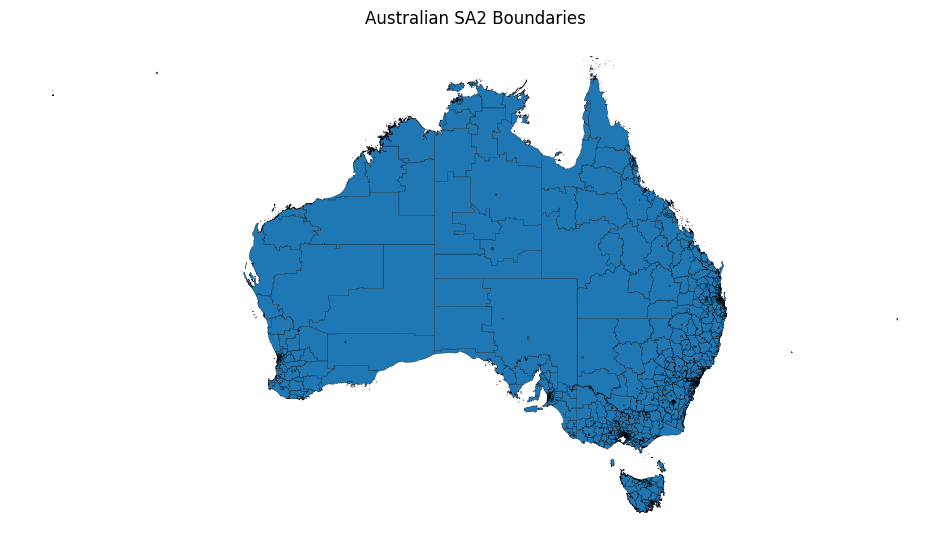

In [15]:
import matplotlib.pyplot as plt

sa2_boundaries.plot(
    figsize=(12, 10),
    edgecolor="black",
    linewidth=0.2
)

plt.title("Australian SA2 Boundaries")
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd
CURATED_DIR = "../data/curated/curated_transactions/part_2.parquet"

# Load the ETL curated transaction level dataset 
curated_df = pd.read_parquet(CURATED_DIR)
print(curated_df.head())
print(curated_df.columns.tolist())

['user_id', 'merchant_abn', 'dollar_value', 'order_id', 'order_datetime', 'name_consumer', 'address', 'state', 'postcode', 'gender', 'consumer_id', 'name_merchant', 'tags', 'consumer_fraud_probability', 'merchant_fraud_probability', 'consumer_is_fraud', 'merchant_is_fraud', 'POA_CODE_2021', 'SA2_CODE_2021', 'mb_count', 'poa_total', 'ratio', 'SA2_NAME_2021', 'disadvantage_score', 'disadvantage_decile', 'adv_disadv_score', 'adv_disadv_decile', 'economic_resources_score', 'economic_resources_decile', 'education_occupation_score', 'education_occupation_decile', 'usual_resident_population']


In [20]:
# Checking for missing values in SA2 in the curated df
SA2_COL = "SA2_CODE_2021" 

print("Missing SA2:", curated_df[SA2_COL].isna().sum())
print("Total rows:", len(curated_df))
print(
    "Missing SA2 percentage:",
    round(curated_df[SA2_COL].isna().mean() * 100, 2),
    "%" \
    ""
)

Missing SA2: 600030
Total rows: 3643266
Missing SA2 percentage: 16.47 %


In [21]:
BOUNDARY_SA2_COL = "SA2_CODE21"  # Replace with actual column name

curated_df[SA2_COL] = curated_df[SA2_COL].astype("string").str.strip()
sa2_boundaries[BOUNDARY_SA2_COL] = sa2_boundaries[BOUNDARY_SA2_COL].astype("string").str.strip()

print("Unique transaction SA2s:", curated_df[SA2_COL].nunique())
print("Unique boundary SA2s:", curated_df[BOUNDARY_SA2_COL].nunique())


Unique transaction SA2s: 1491


KeyError: 'SA2_CODE21'

In [ ]:
BOUNDARY_SA2_COL = "SA2_CODE21"  # Replace with actual column name

curated_df[SA2_COL] = curated_df[SA2_COL].astype("string").str.strip()
sa2_boundaries[BOUNDARY_SA2_COL] = sa2_boundaries[BOUNDARY_SA2_COL].astype("string").str.strip()

print("Unique transaction SA2s:", curated_df[SA2_COL].nunique())
print("Unique boundary SA2s:", curated_df[BOUNDARY_SA2_COL].nunique())



TRANSACTION_ID_COL = "order_id"  # Adapt this
AMOUNT_COL = "amount"                  # Adapt this

sa2_activity = (
    transactions.dropna(subset=[SA2_COL])
    .groupby(SA2_COL)
    .agg(
        transaction_count=(TRANSACTION_ID_COL, "count"),
        total_spend=(AMOUNT_COL, "sum"),
        average_transaction_value=(AMOUNT_COL, "mean"),
        unique_consumers=("consumer_id", "nunique")
    )
    .reset_index()
)

sa2_activity.head()



geo_data = sa2.merge(
    sa2_activity,
    left_on=BOUNDARY_SA2_COL,
    right_on=SA2_COL,
    how="left"
)

geo_data["transaction_count"] = (
    geo_data["transaction_count"].fillna(0)
)

print(geo_data.shape)
geo_data[["transaction_count", "total_spend"]].describe()

['user_id', 'merchant_abn', 'dollar_value', 'order_id', 'order_datetime', 'name_consumer', 'address', 'state', 'postcode', 'gender', 'consumer_id', 'name_merchant', 'tags', 'consumer_fraud_probability', 'merchant_fraud_probability', 'consumer_is_fraud', 'merchant_is_fraud', 'POA_CODE_2021', 'SA2_CODE_2021', 'mb_count', 'poa_total', 'ratio', 'SA2_NAME_2021', 'disadvantage_score', 'disadvantage_decile', 'adv_disadv_score', 'adv_disadv_decile', 'economic_resources_score', 'economic_resources_decile', 'education_occupation_score', 'education_occupation_decile', 'usual_resident_population']


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

geo_data.plot(
    column="transaction_count",
    cmap="Blues",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No matched data"
    },
    legend_kwds={
        "label": "Number of transactions",
        "shrink": 0.6
    }
)

ax.set_title("BNPL Transaction Activity by SA2")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# 3. Read ABS Spatial Boundary Shapefile / GeoJSON
# (Download SA2_2021_AUST_GDA2020.shp or GeoJSON from ABS)
gdf_sa2 = gpd.read_file("path/to/SA2_2021_AUST.geojson")

# Ensure SA2 code column data types match (string vs string)
gdf_sa2["SA2_CODE21"] = gdf_sa2["SA2_CODE21"].astype(str)
sa2_summary["SA2_CODE_2021"] = sa2_summary["SA2_CODE_2021"].astype(str)

# 4. Merge Spatial geometries with aggregated attributes
merged_gdf = gdf_sa2.merge(
    sa2_summary, left_on="SA2_CODE21", right_on="SA2_CODE_2021", how="inner"
)

# 5. Interactive Choropleth Map using Plotly
fig = px.choropleth_mapbox(
    merged_gdf,
    geojson=merged_gdf.__geo_interface__,
    locations=merged_gdf.index,
    color="avg_income",
    hover_name="SA2_NAME_2021",
    hover_data=["consumer_count", "avg_income"],
    mapbox_style="carto-positron",
    zoom=4,
    center={"lat": -25.2744, "lon": 133.7751},
    title="Weekly Household Income by SA2",
)
fig.show()